# Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import tracemalloc as tm

In [2]:
df = pd.read_csv('Datasets/vote1.csv')
df.head(3)

,state,district,democA,voteA,expendA,expendB,prtystrA,lexpendA,lexpendB,shareA
0,PA,17,1,65.4,271.1,126.8,54.7,5.602,4.843,68.13
1,NY,17,1,56.6,60.3,88.9,50.5,4.099,4.488,40.42
2,OH,17,1,59.0,206.8,268.2,72.8,5.332,5.592,43.54


In [3]:
len(df)

173

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   state     173 non-null    object 
 1   district  173 non-null    int64  
 2   democA    173 non-null    int64  
 3   voteA     173 non-null    float64
 4   expendA   173 non-null    float64
 5   expendB   173 non-null    float64
 6   prtystrA  173 non-null    float64
 7   lexpendA  173 non-null    float64
 8   lexpendB  173 non-null    float64
 9   shareA    173 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 13.6+ KB


In [5]:
df.head(3)

,state,district,democA,voteA,expendA,expendB,prtystrA,lexpendA,lexpendB,shareA
0,PA,17,1,65.4,271.1,126.8,54.7,5.602,4.843,68.13
1,NY,17,1,56.6,60.3,88.9,50.5,4.099,4.488,40.42
2,OH,17,1,59.0,206.8,268.2,72.8,5.332,5.592,43.54


# Formulas

In [6]:
def R2(y_data:np.array, y_pred:np.array):
  y_mean = np.mean(y_data)

  ss_tot = np.sum((y_data - y_mean)**2)
  ss_res = np.sum((y_data - y_pred)**2)
  r2 = 1 - (ss_res/ss_tot)

  return r2

In [7]:
# Regresion lineal: y = mx + b

Fórmulas de regresión lineal multiple

$$a = \sum_{i=1}^{n}x_{1i}$$
$$A = \sum_{i=1}^{n}x_{1i}^2$$
$$b = \sum_{i=1}^{n}x_{2i}$$
$$B = \sum_{i=1}^{n}x_{2i}^2$$
$$c = \sum_{i=1}^{n}x_{1i}x_{2i}$$

$$d_1=\sum_{i=1}^{n}{y_i}$$
$$d_2=\sum_{i=1}^{n}{y_ix_{1i}}$$
$$d_3=\sum_{i=1}^{n}{y_ix_{2i}}$$

Determinante:
$$D=n(AB-c^2)-a^2B+2abc-b^2A$$

$$\alpha_0=\frac{(AB-c^2)d_1+(bc-aB)d_2+(ac-bA)d_3}{D}$$
$$\alpha_1=\frac{(bc-aB)d_1+(nB-b^2)d_2+(ab-nc)d_3}{D}$$
$$\alpha_2=\frac{(ac-bA)d_1+(ab-nc)d_2+(nA-a^2)d_3}{D}$$

In [8]:
class RegresionLineal2Vars():
  def __init__(self, y_data:np.array, x1_data:np.array, x2_data:np.array) -> None:
    self.n = len(y_data)
    self.x1_data = x1_data
    self.x2_data = x2_data
    self.y_data = y_data

  def fit(self) -> None:
    t_0 = time.time()
    tm.start()

    n = self.n

    a = np.sum(self.x1_data)
    A = np.sum(self.x1_data**2)
    b = np.sum(self.x2_data)
    B = np.sum(self.x2_data**2)
    c = np.sum(self.x1_data*self.x2_data)

    d1 = np.sum(self.y_data)
    d2 = np.sum(self.y_data*self.x1_data)
    d3 = np.sum(self.y_data*self.x2_data)

    D = n*(A*B - c**2) - a**2*B + 2*a*b*c - b**2*A

    p1 = A*B - c**2
    p2 = b*c - a*B
    p3 = a*c - b*A
    self.alpha0 = (p1*d1 + p2*d2 + p3*d3)/D
    p1 = b*c - a*B
    p2 = n*B - b**2
    p3 = a*b - n*c
    self.alpha1 = (p1*d1 + p2*d2 + p3*d3)/D
    p1 = a*c - b*A
    p2 = a*b - n*c
    p3 = n*A - a**2
    self.alpha2 = (p1*d1 + p2*d2 + p3*d3)/D

    self.total_memory, self.peak_memory = tm.get_traced_memory()
    tm.stop()
    t_f = time.time()
    self.time = t_f - t_0

  def return_params(self) -> list:
    return [self.alpha0, self.alpha1, self.alpha2]

  def name_vars(self, y_name:str, x_1_name:str, x_2_name:str) -> None:
    self.y_name = y_name
    self.x_1_name = x_1_name
    self.x_2_name = x_2_name

  def __str__(self) -> str:
    return f"{self.y_name} = {self.alpha0} + {self.alpha1}*{self.x_1_name} + {self.alpha2}*{self.x_2_name}"

  def print_efficiency_details(self) -> None:
    print("Tiempo de Aprendizaje: ", self.time, "s", sep="")
    print("Memoria Total: ", self.total_memory, "B", sep="")
    print("Memoria Maxima: ", self.peak_memory, "B", sep="")

  def predict(self, x1_data:np.array, x2_data:np.array) -> np.array:
    return self.alpha0*np.ones(len(x1_data)) + self.alpha1*x1_data + self.alpha2*x2_data

In [9]:
class RegresionLineal2VarGradient():
  def __init__(self, y_data:np.array, x1_data:np.array, x2_data:np.array) -> None:
    self.n = len(y_data)
    self.x1_data = x1_data
    self.x2_data = x2_data
    self.y_data = y_data

    self.MSEs = []

  def end(self, t_0:float, alphas:tuple) -> None:
    self.alpha0 = alphas[0]
    self.alpha1 = alphas[1]
    self.alpha2 = alphas[2]

    self.total_memory, self.peak_memory = tm.get_traced_memory()
    tm.stop()
    t_f = time.time()
    self.time = t_f - t_0

  def fit(self, learning_rate:float, epochs:int, tolerance:float, start:tuple) -> None:
    alpha0 = start[0]
    alpha1 = start[1]
    alpha2 = start[2]

    t_0 = time.time()
    tm.start()

    for i in range(epochs):
      y_pred = alpha0 + alpha1*self.x1_data + alpha2*self.x2_data
      mse = np.mean((y_pred - self.y_data)**2)/2

      self.MSEs.append(mse)

      if len(self.MSEs) != 1:
        if (np.abs(self.MSEs[-2] - mse)) < tolerance:
          self.last_epoch = i
          self.end(t_0, (alpha0, alpha1, alpha2))
          return

      alpha0 -= learning_rate*np.sum(y_pred - self.y_data)/self.n
      alpha1 -= learning_rate*np.dot((y_pred - self.y_data), self.x1_data)/self.n
      alpha2 -= learning_rate*np.dot((y_pred - self.y_data), self.x2_data)/self.n

    self.last_epoch = epochs
    self.end(t_0, (alpha0, alpha1, alpha2))

  def return_params(self) -> list:
    return [self.alpha0, self.alpha1, self.alpha2]

  def name_vars(self, y_name:str, x_1_name:str, x_2_name:str) -> None:
    self.y_name = y_name
    self.x_1_name = x_1_name
    self.x_2_name = x_2_name

  def __str__(self) -> str:
    return f"{self.y_name} = {self.alpha0} + {self.alpha1}*{self.x_1_name} + {self.alpha2}*{self.x_2_name}"

  def print_efficiency_details(self) -> None:
    print("Tiempo de Aprendizaje: ", self.time, "s", sep="")
    print("Memoria Total: ", self.total_memory, "B", sep="")
    print("Memoria Maxima: ", self.peak_memory, "B", sep="")
    print("Numero de Epochs:", self.last_epoch, "Epochs")

  def predict(self, x1_data:np.array, x2_data:np.array) -> np.array:
    return self.alpha0*np.ones(len(x1_data)) + self.alpha1*x1_data + self.alpha2*x2_data

## Fórmulas de regresión lineal simple

Para el modelo de una sola variable $y=\alpha_0+\alpha_1x$, los estimadores que minimizan la suma de errores al cuadrado (mínimos cuadrados ordinarios) están dados por:

$$\alpha_1=\frac{n\sum_{i=1}^{n}x_iy_i-\left(\sum_{i=1}^{n}x_i\right)\left(\sum_{i=1}^{n}y_i\right)}{n\sum_{i=1}^{n}x_i^2-\left(\sum_{i=1}^{n}x_i\right)^2}$$

$$\alpha_0=\bar{y}-\alpha_1\bar{x}$$

In [10]:
class RegresionLinealSimple():
  def __init__(self, y_data:np.array, x_data:np.array) -> None:
    self.n = len(y_data)

    self.sum_x = np.sum(x_data)
    self.sum_x2 = np.sum(x_data**2)
    self.sum_y = np.sum(y_data)
    self.sum_xy = np.sum(x_data*y_data)

    self.alpha1 = (self.n*self.sum_xy - self.sum_x*self.sum_y) / (self.n*self.sum_x2 - self.sum_x**2)
    self.alpha0 = (self.sum_y - self.alpha1*self.sum_x) / self.n

  def return_params(self) -> list:
    return [self.alpha0, self.alpha1]

  def name_vars(self, y_name:str, x_name:str) -> None:
    self.y_name = y_name
    self.x_name = x_name

  def __str__(self) -> str:
    return f"{self.y_name} = {self.alpha0} + {self.alpha1}*{self.x_name}"

  def predict(self, x_data:np.array) -> np.array:
    return self.alpha0*np.ones(len(x_data)) + self.alpha1*x_data

In [11]:
# Resumen con errores estándar, t y R^2 ajustada (sin statsmodels, solo álgebra matricial)
def resumen(y_data:np.array, X:np.array) -> None:
  # X: matriz n x k con las variables independientes (sin la columna de unos)
  n, k = X.shape
  Xc = np.column_stack([np.ones(n), X])
  XtX_inv = np.linalg.inv(Xc.T @ Xc)
  alpha = XtX_inv @ Xc.T @ y_data
  res = y_data - Xc @ alpha
  sigma2 = (res @ res) / (n - k - 1)
  se = np.sqrt(np.diag(sigma2 * XtX_inv))
  r2 = 1 - (res @ res) / np.sum((y_data - np.mean(y_data))**2)
  r2_aj = 1 - (1 - r2) * (n - 1) / (n - k - 1)
  print("alpha:", alpha)
  print("Error estándar:", se)
  print("t:", alpha / se)
  print("R^2:", r2, " R^2 ajustada:", r2_aj)

# Experimentos

## a.
$voteA=\alpha_0+\alpha_1*shareA$

Fórmulas Directas

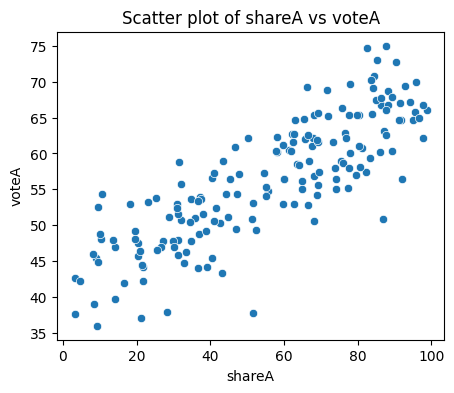

In [12]:
plt.figure(figsize=(5, 4))
sns.scatterplot(data=df, x="shareA", y="voteA")
plt.title("Scatter plot of shareA vs voteA")
plt.xlabel("shareA")
plt.ylabel("voteA")
plt.show()

In [13]:
x_a = df["shareA"].to_numpy()
y_a = df["voteA"].to_numpy()

In [14]:
model_a = RegresionLinealSimple(y_a, x_a)
model_a.name_vars("voteA", "shareA")

In [15]:
print(model_a)

voteA = 41.263529818691325 + 0.2704380417765019*shareA


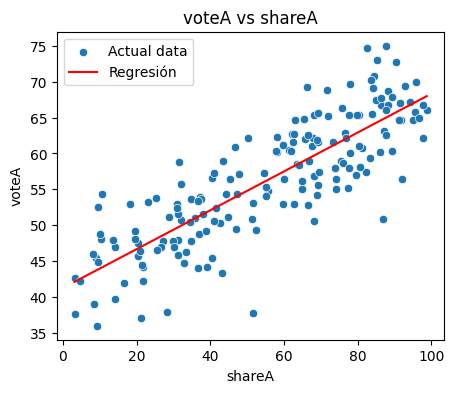

In [16]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x=x_a, y=y_a, label="Actual data")
x_line = np.linspace(x_a.min(), x_a.max(), 100)
plt.plot(x_line, model_a.predict(x_line), color="red", label="Regresión")
plt.title("voteA vs shareA")
plt.xlabel("shareA")
plt.ylabel("voteA")
plt.legend()
plt.show()

In [17]:
print("R^2:", R2(y_a, model_a.predict(x_a)))
resumen(y_a, x_a.reshape(-1, 1))

R^2: 0.6897360166204147
alpha: [41.26352982  0.27043804]
Error estándar: [0.85024024 0.01387056]
t: [48.53161265 19.49727088]
R^2: 0.6897360166204147  R^2 ajustada: 0.6879216073608849


## b.
$voteA=\alpha_0+\alpha_1*expendA$

Fórmulas Directas

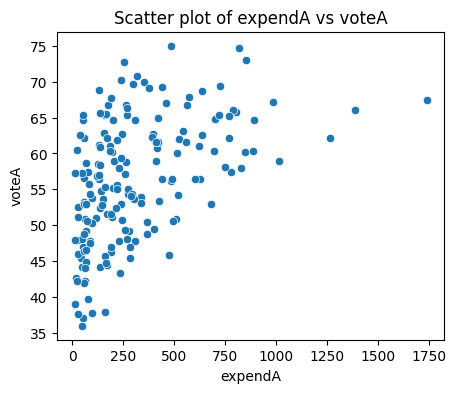

In [18]:
plt.figure(figsize=(5, 4))
sns.scatterplot(data=df, x="expendA", y="voteA")
plt.title("Scatter plot of expendA vs voteA")
plt.xlabel("expendA")
plt.ylabel("voteA")
plt.show()

In [19]:
x_b = df["expendA"].to_numpy()
y_b = df["voteA"].to_numpy()

In [20]:
model_b = RegresionLinealSimple(y_b, x_b)
model_b.name_vars("voteA", "expendA")

In [21]:
print(model_b)

voteA = 51.75456331779568 + 0.014435158564222861*expendA


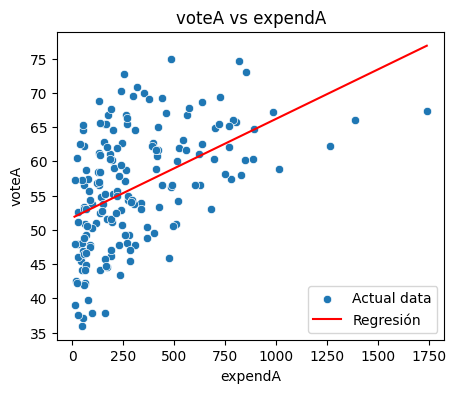

In [22]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x=x_b, y=y_b, label="Actual data")
x_line = np.linspace(x_b.min(), x_b.max(), 100)
plt.plot(x_line, model_b.predict(x_line), color="red", label="Regresión")
plt.title("voteA vs expendA")
plt.xlabel("expendA")
plt.ylabel("voteA")
plt.legend()
plt.show()

In [23]:
print("R^2:", R2(y_b, model_b.predict(x_b)))

R^2: 0.23145326871175276


In [24]:
resumen(y_b, x_b.reshape(-1, 1))

alpha: [5.17545633e+01 1.44351586e-02]
Error estándar: [0.84851327 0.00201153]
t: [60.99440639  7.17620067]
R^2: 0.2314532687117531  R^2 ajustada: 0.2269588433825821


¿Qué nos dicen los respectivos coeficientes $\alpha_0$, $\alpha_1$ y $\alpha_2$?
* $\alpha_0$: Es el valor esperado de la variable dependiente (voteA) cuando la variable independiente (expendA) es igual a cero.
* $\alpha_1$: Indica el cambio promedio en la variable dependiente (voteA) por cada unidad de aumento en la variable independiente (expendA).

Con respecto al archivo
* $\alpha_0$: Si un candidato no gasta nada de dinero (expendA = 0), se espera que obtenga aproximadamente un 51.75% de los votos. Esto es una extrapolación al borde de los datos, y sale alto porque `expendA` no considera cuánto gasta el rival.
* $\alpha_1$: Por cada unidad adicional de gasto (en el conjunto de datos original, miles de dólares), el porcentaje de votos aumenta en 0.0144 puntos porcentuales. En una escala más útil, cada 100 unidades más de gasto suben `voteA` aproximadamente 1.4 puntos porcentuales.
* $R^2 = 0.2314$: el gasto propio explica solo cerca del 23% de la variación de `voteA`. Es bajo porque el gasto de un candidato no dice nada sobre el gasto de su rival, y en una elección importa la comparación entre ambos (justo lo que sí contiene `shareA`).

## c.
$voteA=\alpha_0+\alpha_1*shareA+\alpha_2*expendA$

Fórmulas Directas

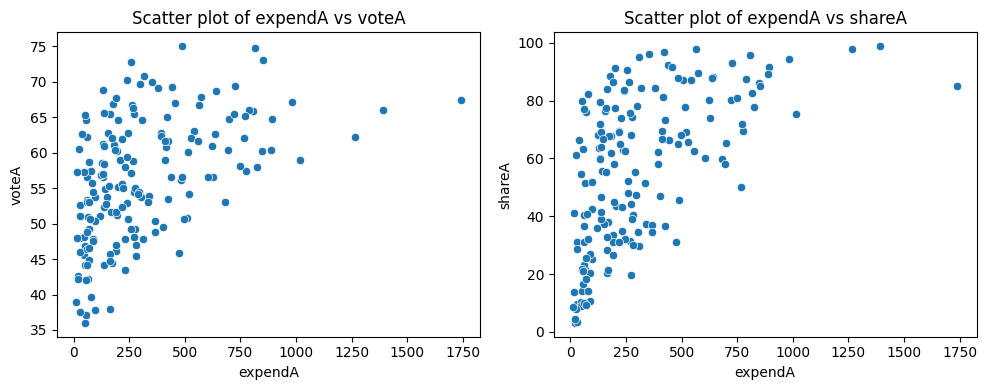

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df, x="expendA", y="voteA", ax=axs[0])
axs[0].set_title("Scatter plot of expendA vs voteA")
sns.scatterplot(data=df, x="expendA", y="shareA", ax=axs[1])
axs[1].set_title("Scatter plot of expendA vs shareA")
plt.tight_layout()
plt.show()

In [26]:
x_1 = df["shareA"].to_numpy()
x_2 = df["expendA"].to_numpy()
y = df["voteA"].to_numpy()

In [27]:
model = RegresionLineal2Vars(y, x_1, x_2)
model.fit()
model.name_vars("voteA", "shareA", "expendA")

In [28]:
print(model)

voteA = 41.25722374403411 + 0.2714309707896134*shareA + -0.00015681610841925884*expendA


$voteA = 41.2572 + 0.2714*shareA - 0.00016*expendA$

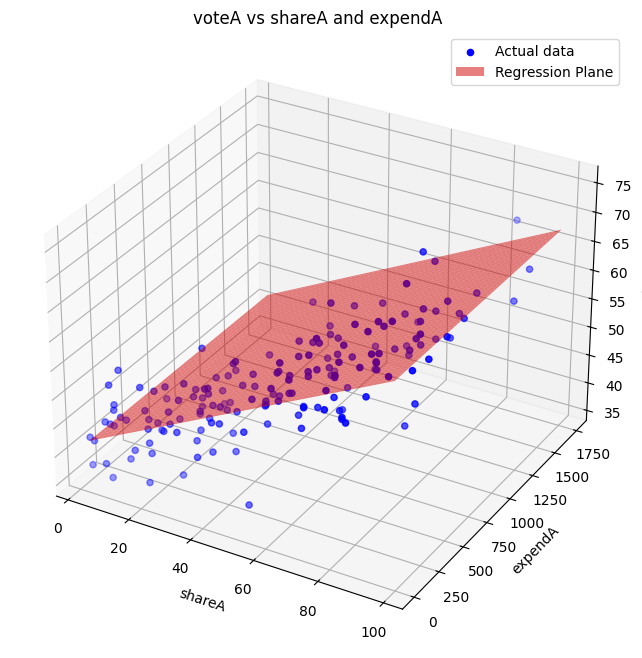

In [29]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_1, x_2, y, c='blue', marker='o', label='Actual data')
x1_surf, x2_surf = np.meshgrid(np.linspace(x_1.min(), x_1.max(), 100), np.linspace(x_2.min(), x_2.max(), 100))
y_surf = model.alpha0 + model.alpha1 * x1_surf + model.alpha2 * x2_surf
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.5, label='Regression Plane')

ax.set_xlabel('shareA')
ax.set_ylabel('expendA')
ax.set_zlabel('voteA')
ax.set_title('voteA vs shareA and expendA')

ax.legend()
plt.show()

In [30]:
print("R^2:", R2(y, model.predict(x_1, x_2)))

R^2: 0.6897540337660086


In [31]:
resumen(y, np.column_stack([x_1, x_2]))

alpha: [ 4.12572237e+01  2.71430971e-01 -1.56816108e-04]
Error estándar: [0.85507113 0.01712824 0.00157825]
t: [48.25004884 15.84698621 -0.09936064]
R^2: 0.6897540337660086  R^2 ajustada: 0.6861040812220793


In [32]:
model.print_efficiency_details()

Tiempo de Aprendizaje: 0.0007710456848144531s
Memoria Total: 360B
Memoria Maxima: 2520B


¿Qué nos dicen los respectivos coeficientes $\alpha_0$, $\alpha_1$ y $\alpha_2$?
* $\alpha_0$: Este simplemente se interpreta como el intercepto, donde, si todas las variables son 0, este sería el valor base.
* $\alpha_1$: Podemos notar que en el gráfico entre `ShareA` y `VoteA`, sí existe una relación lineal con cierta dispersión entre algunos datos, pero la forma en general es lineal y este valor describe la pendiente: manteniendo `ExpendA` constante, por cada punto porcentual adicional en `ShareA`, `VoteA` aumenta 0.27 puntos porcentuales.
* $\alpha_2$: Este valor es cercano a 0 ($-0.00016$), y con signo negativo, contrario a lo intuitivo. Es el efecto de `ExpendA` manteniendo `ShareA` constante, lo que equivale a que ambos candidatos gastan más en la misma proporción (cambia la escala total del gasto, no la proporción). Que el $R^2$ prácticamente no cambie respecto al modelo con solo `ShareA` (0.6897 contra 0.68975) indica que `ExpendA` no aporta a la regresión lineal. Esto se confirma con el error estándar y el estadístico $t$ de la celda de `resumen` (si $|t|<2$, no se distingue de 0).

## d.
$voteA=\alpha_0+\alpha_1*shareA+\alpha_2*expendB$

Fórmulas Directas

In [33]:
x_1 = df["shareA"].to_numpy()
x_2 = df["expendB"].to_numpy()
y = df["voteA"].to_numpy()

In [34]:
model = RegresionLineal2Vars(y, x_1, x_2)
model.fit()
model.name_vars("voteA", "shareA", "expendB")

In [35]:
print(model)

voteA = 40.91580961589031 + 0.27390166199822097*shareA + 0.0006587566231264047*expendB


$voteA = 40.9158 + 0.2739*shareA + 0.00066*expendB$

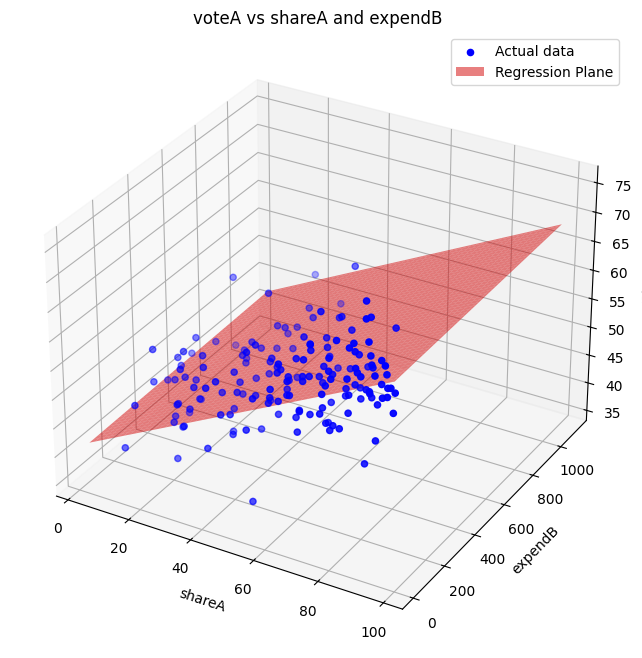

In [36]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_1, x_2, y, c='blue', marker='o', label='Actual data')
x1_surf, x2_surf = np.meshgrid(np.linspace(x_1.min(), x_1.max(), 100), np.linspace(x_2.min(), x_2.max(), 100))
y_surf = model.alpha0 + model.alpha1 * x1_surf + model.alpha2 * x2_surf
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.5, label='Regression Plane')

ax.set_xlabel('shareA')
ax.set_ylabel('expendB')
ax.set_zlabel('voteA')
ax.set_title('voteA vs shareA and expendB')

ax.legend()
plt.show()

In [37]:
print("R^2:", R2(y, model.predict(x_1, x_2)))

R^2: 0.689897400397087


In [38]:
resumen(y, np.column_stack([x_1, x_2]))

alpha: [4.09158096e+01 2.73901662e-01 6.58756623e-04]
Error estándar: [1.44686902 0.01813898 0.00221474]
t: [28.27886214 15.10016733  0.29744159]
R^2: 0.689897400397087  R^2 ajustada: 0.6862491345194057


In [39]:
model.print_efficiency_details()

Tiempo de Aprendizaje: 0.0004532337188720703s
Memoria Total: 432B
Memoria Maxima: 2592B


In [40]:
df["artificial_shareA"] = df["expendA"]/(df["expendA"]+df["expendB"])*100
df["diff"] = (df["artificial_shareA"] - df["shareA"]).abs()
df["diff"] = df["diff"].map(lambda x: "Identical" if float(x) < 0.01 else "Different")
df["diff"].value_counts()

diff
Identical    173
Name: count, dtype: int64

¿Qué nos dicen los respectivos coeficientes $\alpha_0$, $\alpha_1$ y $\alpha_2$?
* $\alpha_0$: Este simplemente se interpreta como el intercepto, donde, si todas las variables son 0, este sería el valor base.
* $\alpha_1$: Podemos notar que en el gráfico entre `ShareA` y `VoteA`, sí existe una relación lineal con cierta dispersión entre algunos datos, pero la forma en general es lineal y este valor describe la pendiente: manteniendo `ExpendB` constante, por cada punto porcentual adicional en `ShareA`, `VoteA` aumenta 0.27 puntos porcentuales.
* $\alpha_2$: Este valor es cercano a 0 ($+0.00066$), por lo que se entiende que en general la variable `ExpendB` no es influyente para la regresión lineal. Además, su signo es positivo aquí y negativo para `ExpendA` en el inciso anterior, lo que es típico de un coeficiente que no se distingue de 0 (si el gasto del rival tuviera un efecto real, esperaríamos que perjudicara a A).
<br>En ambos casos, al añadir `ExpendA` o `ExpendB`, no se aportó información nueva, pues `ShareA` ya resume la información de ambos al ser el porcentaje del gasto total que corresponde al candidato A, derivado de la fórmula:
$$share_A=\frac{expend_A}{expend_A+expend_B}*100$$
Como `ShareA` es una función de estas variables (un cociente, no una combinación lineal), no hay multicolinealidad perfecta, pero sí comparten información, lo que puede causar cierta multicolinealidad moderada e inestabilidad en los coeficientes. Añadir estas variables es redundante: $R^2$ apenas cambia (0.6897 → 0.68975 y 0.68990) y la $R^2$ ajustada baja.

## e.
$voteA=\alpha_0+\alpha_1*shareA$

Gradiente Descenciente

voteA = 41.092134920577045 + 0.27296313681050227*shareA
R^2: 0.6896622860266288
Épocas usadas: 2972353
Tiempo: 163.07678842544556 segundos
Memoria pico: 95.753323 Mb, actual: 95.732567 Mb


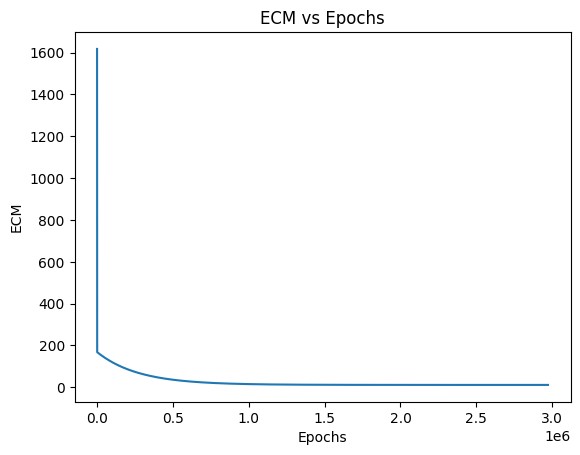

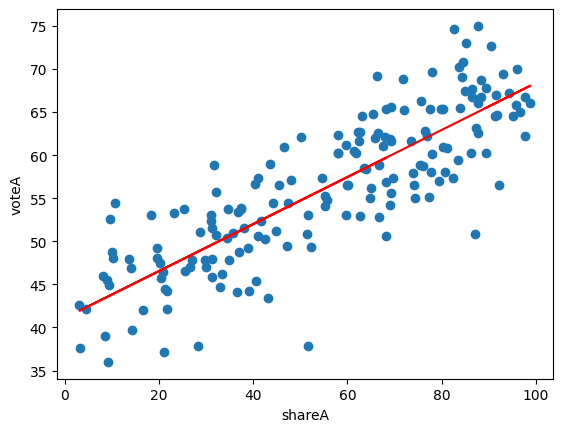

In [41]:
x1 = df["shareA"].to_numpy()
Y_datos = df["voteA"].to_numpy()
m = len(x1)

#Definir parámetros
lr = 1e-5
a0, a1 = 0.0, 0.0
epochs = 10_000_000
epsilon = 1e-8

ECM = []
ECMA, ECMB = 20, 0
epocas = 0

#Medición del tiempo
tiempo_inicial = time.time()
tm.start()

while epocas < epochs and np.abs(ECMA - ECMB) > epsilon:
  #Calcular Y del modelo propuesto
  y_obt = a0 + a1 * x1
  ecm = (1/(2*m)) * np.sum((Y_datos - y_obt)**2)
  ECM.append(ecm)

  #Calcular a0, a1
  a0 = a0 - lr * np.sum(y_obt - Y_datos) / m
  a1 = a1 - lr * np.dot((y_obt - Y_datos), x1) / m

  #Guardar los errores presente y pasado
  ECMB = ECMA
  ECMA = ecm
  #Incremento del iterador
  epocas += 1

#Tiempo final, memoria pico y actual usada
tiempo_fin = time.time()
actual, pico = tm.get_traced_memory()
tm.stop()

print(f"voteA = {a0} + {a1}*shareA")
print("R^2:", R2(Y_datos, a0 + a1 * x1))
print(f"Épocas usadas: {epocas}")
print(f"Tiempo: {tiempo_fin - tiempo_inicial} segundos")
print(f"Memoria pico: {pico/10**6} Mb, actual: {actual/10**6} Mb")

plt.figure()
plt.plot(ECM)
plt.title("ECM vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("ECM")
plt.show()

plt.figure()
plt.scatter(x1, Y_datos)
plt.plot(x1, a0 + a1 * x1, color="red")
plt.xlabel("shareA")
plt.ylabel("voteA")
plt.show()

## f.
$voteA=\alpha_0+\alpha_1*expendA$

Gradiente Descenciente

In [42]:
x1 = df["expendA"].to_numpy()
Y_datos = df["voteA"].to_numpy()
m = len(x1)

#Definir parámetros
lr = 1e-5
a0, a1 = 0.0, 0.0
epochs = 10_000_000
epsilon = 1e-8

ECM = []
ECMA, ECMB = 20, 0
epocas = 0

In [43]:
#Medición del tiempo
tiempo_inicial = time.time()
tm.start()

In [44]:
#Medición del tiempo
tiempo_inicial = time.time()
tm.start()

while epocas < epochs and np.abs(ECMA - ECMB) > epsilon:
  #Calcular Y del modelo propuesto
  y_obt = a0 + a1 * x1
  ecm = (1/(2*m)) * np.sum((Y_datos - y_obt)**2)
  ECM.append(ecm)

  #Calcular a0, a1
  a0 = a0 - lr * np.sum(y_obt - Y_datos) / m
  a1 = a1 - lr * np.dot((y_obt - Y_datos), x1) / m

  #Guardar los errores presente y pasado
  ECMB = ECMA
  ECMA = ecm
  #Incremento del iterador
  epocas += 1

#Tiempo final, memoria pico y actual usada
tiempo_fin = time.time()
actual, pico = tm.get_traced_memory()
tm.stop()


In [45]:
print(f"voteA = {a0} + {a1}*expendA")
print("R^2:", R2(Y_datos, a0 + a1 * x1))
print(f"Épocas usadas: {epocas}")
print(f"Tiempo: {tiempo_fin - tiempo_inicial} segundos")
print(f"Memoria pico: {pico/10**6} Mb, actual: {actual/10**6} Mb")


voteA = 51.68565929456679 + 0.014555312576180679*expendA
R^2: 0.23142363090570806
Épocas usadas: 1442805
Tiempo: 81.4081175327301 segundos
Memoria pico: 46.737504 Mb, actual: 46.716748 Mb


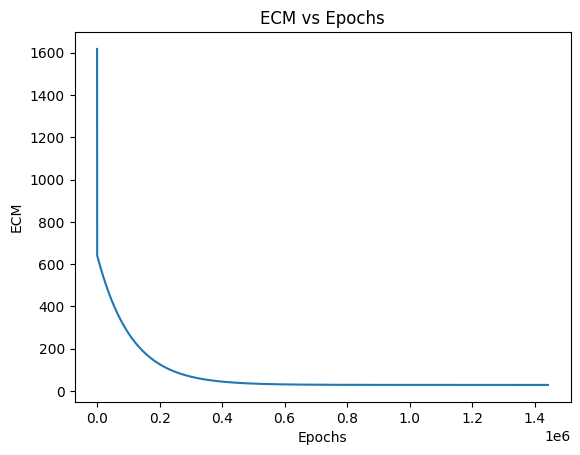

In [46]:
plt.figure()
plt.plot(ECM)
plt.title("ECM vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("ECM")
plt.show()


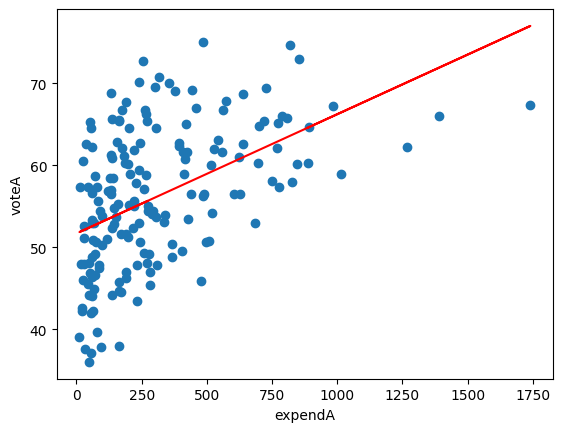

In [47]:
plt.figure()
plt.scatter(x1, Y_datos)
plt.plot(x1, a0 + a1 * x1, color="red")
plt.xlabel("expendA")
plt.ylabel("voteA")
plt.show() 

## g.
$voteA=\alpha_0+\alpha_1*shareA+\alpha_2*expendA$

Gradiente Descenciente

In [48]:
x_1 = df["shareA"].to_numpy()
x_2 = df["expendA"].to_numpy()
y = df["voteA"].to_numpy()

In [49]:
model = RegresionLineal2VarGradient(y, x_1, x_2)
model.fit(1e-5, 10000000, 1e-8, (0,0,0))
model.name_vars("voteA", "shareA", "expendA")

In [50]:
print(model)

voteA = 41.0848769855078 + 0.27410590843100047*shareA + -0.00018047947732771361*expendA


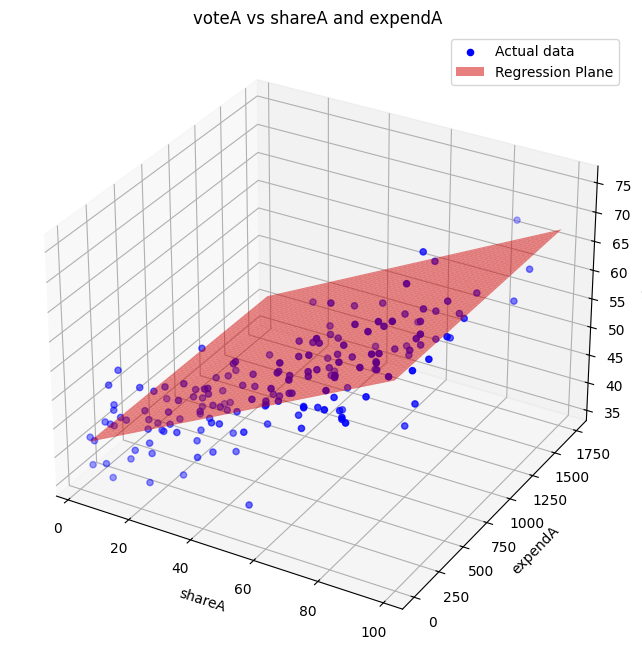

In [51]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_1, x_2, y, c='blue', marker='o', label='Actual data')
x1_surf, x2_surf = np.meshgrid(np.linspace(x_1.min(), x_1.max(), 100), np.linspace(x_2.min(), x_2.max(), 100))
y_surf = model.alpha0 + model.alpha1 * x1_surf + model.alpha2 * x2_surf
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.5, label='Regression Plane')

ax.set_xlabel('shareA')
ax.set_ylabel('expendA')
ax.set_zlabel('voteA')
ax.set_title('voteA vs shareA and expendA')

ax.legend()
plt.show()

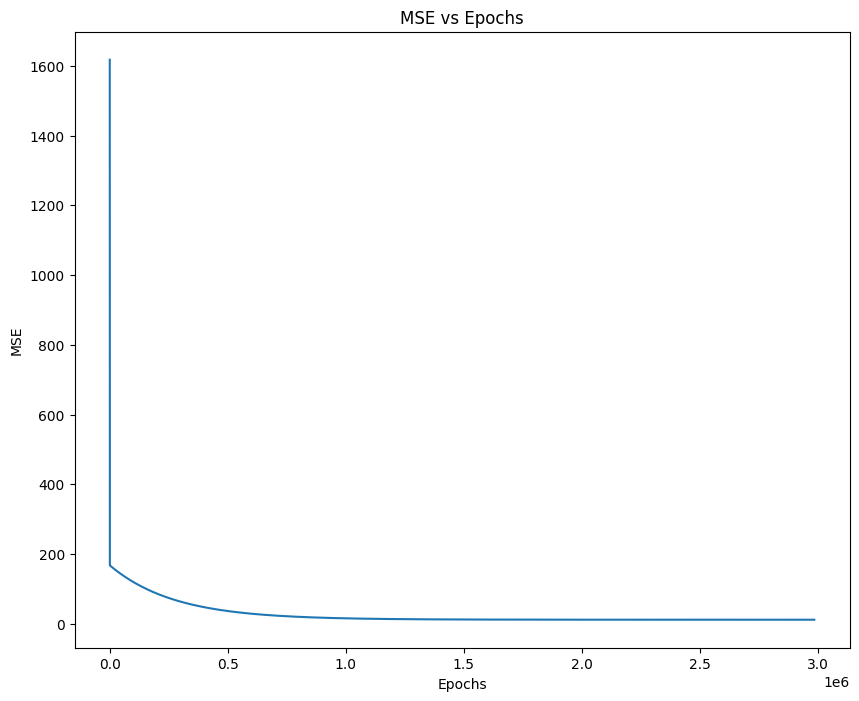

In [52]:
plt.figure(figsize=(10, 8))
plt.plot(model.MSEs)
plt.title("MSE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

In [53]:
print("R^2:", R2(y, model.predict(x_1, x_2)))

R^2: 0.689679892671631


In [54]:
model.print_efficiency_details()

Tiempo de Aprendizaje: 792.3701093196869s
Memoria Total: 96050202B
Memoria Maxima: 96054618B
Numero de Epochs: 2985772 Epochs


## h.
$voteA=\alpha_0+\alpha_1*shareA+\alpha_2*expendB$

Gradiente Descenciente

In [55]:
x_1 = df["shareA"].to_numpy()
x_2 = df["expendB"].to_numpy()
y = df["voteA"].to_numpy()

In [57]:
model = RegresionLineal2VarGradient(y, x_1, x_2)
model.fit(1e-5, 10000000, 1e-8, (0,0,0))
model.name_vars("voteA", "shareA", "expendB")

In [58]:
print(model)

voteA = 40.42214083029894 + 0.2796368797955154*shareA + 0.0012693059522430996*expendB


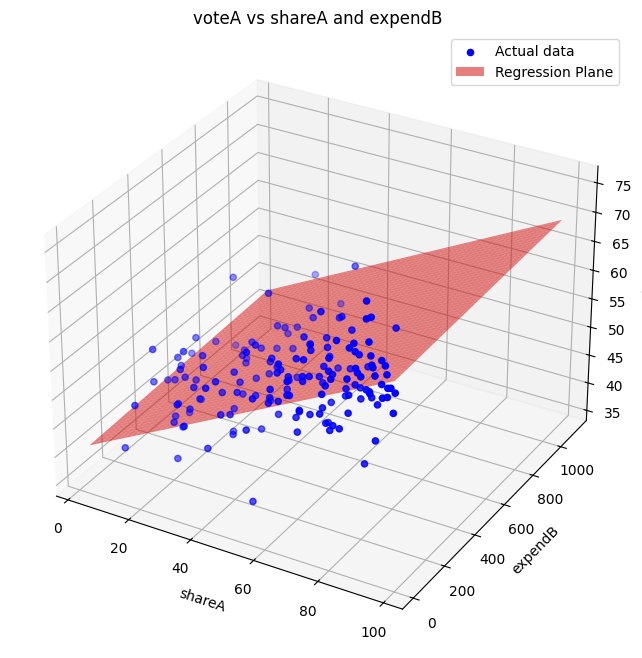

In [59]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_1, x_2, y, c='blue', marker='o', label='Actual data')
x1_surf, x2_surf = np.meshgrid(np.linspace(x_1.min(), x_1.max(), 100), np.linspace(x_2.min(), x_2.max(), 100))
y_surf = model.alpha0 + model.alpha1 * x1_surf + model.alpha2 * x2_surf
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.5, label='Regression Plane')

ax.set_xlabel('shareA')
ax.set_ylabel('expendB')
ax.set_zlabel('voteA')
ax.set_title('voteA vs shareA and expendB')

ax.legend()
plt.show()

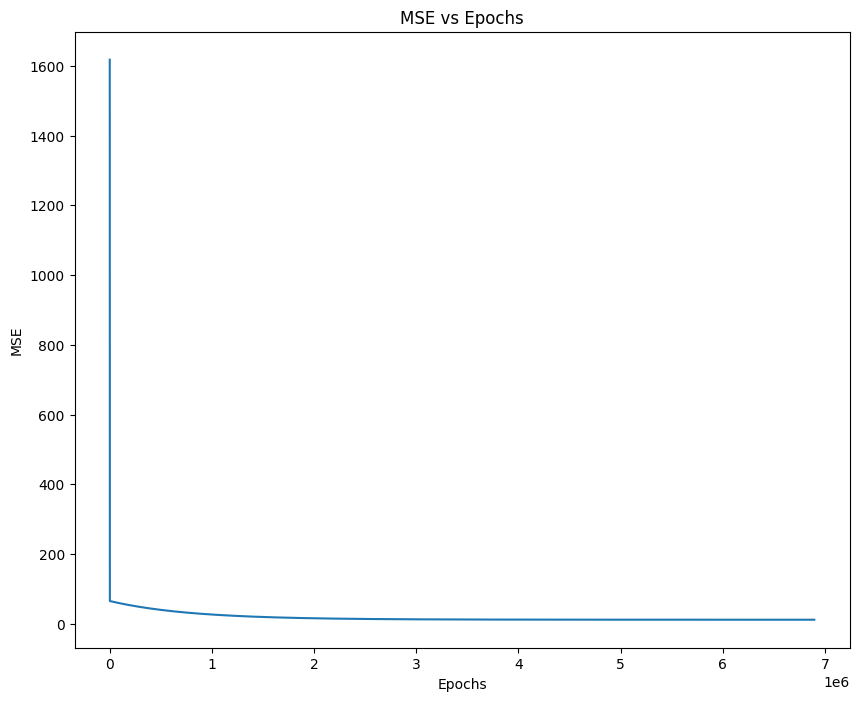

In [60]:
plt.figure(figsize=(10, 8))
plt.plot(model.MSEs)
plt.title("MSE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()

In [61]:
print("R^2:", R2(y, model.predict(x_1, x_2)))

R^2: 0.6896850420257659


In [62]:
model.print_efficiency_details()

Tiempo de Aprendizaje: 733.8872811794281s
Memoria Total: 322798553B
Memoria Maxima: 322803024B
Numero de Epochs: 6896234 Epochs


## Comparación de resultados

| Inciso | Método | Modelo | $R^2$ | Épocas | Tiempo |
|---|---|---|---|---|---|
| c | Exacto | shareA + expendA | 0.68975 | - | 0.0015 s |
| d | Exacto | shareA + expendB | 0.68990 | - | 0.0008 s |
| e | Gradiente | shareA | 0.68966 | 2,972,353 | 556.9 s |
| f | Gradiente | expendA | 0.23142 | 1,442,805 | 190.7 s |
| g | Gradiente | shareA + expendA | 0.68968 | 2,985,772 | 1365.8 s |
| h | Gradiente | shareA + expendB | 0.68969 | 6,896,234 | 1036.4 s |

* Las ecuaciones exactas dan el mínimo del error, por lo que su $R^2$ es siempre igual o mayor que el del gradiente (que se detiene antes de llegar).
* El gradiente tardó tanto porque las variables no están escaladas (`shareA` va de 0 a 100 y `expendA` a más de 1000), lo que obliga a usar un `learning_rate` muy pequeño ($10^{-5}$) y millones de épocas. Además, el criterio de paro por cambio del error (`tolerance`) detiene el algoritmo antes de llegar al mínimo, por eso sus coeficientes difieren un poco de los exactos.
* La memoria del gradiente crece porque se guarda el error de cada época en la lista `MSEs`, no por los datos.
* Estandarizar las variables ($z=(x-\bar{x})/s$) permitiría usar un `learning_rate` mayor y converger en cientos de épocas.

## Modelo elegido
$voteA \approx 41.1 + 0.273*shareA$. Agregar `expendA` o `expendB` no mejora el ajuste ($R^2$ prácticamente igual y $R^2$ ajustada menor), y `expendA` sola explica solo el 23% de `voteA`.